# Desafio 3 - ZettaLab

In [16]:
import pandas as pd             # Biblioteca para manipulação e análise de dados
import numpy as np              # Biblioteca para calculo de vetores e matrizes
import sys                      # Biblioteca para acessar variaveis e funções que interagem fortemente com o interpretador
import os                       # Biblioteca para interação com arquivos e diretórios a nivel sistema operacional

from pathlib import Path        # Biblioteca para a manipulação de caminhos do sistema a nivel orientado a objetos
import lightgbm as lgb
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import gc
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import config_path          # Módulo que salva todos os caminhos de diretórios utilizados no projeto

from api.schemas.schemas import TipoModelo, InfoModelo, ListaModelos  # Schemas Pydantic para validação de dados relacionados a modelos
from scripts import features        # Módulo de criação e manipulação de features
from scripts import modeling        # Módulo de modelagem de IA
from scripts import utils           # Módulo de utilitários genéricos
from scripts import pre_processing  # Módulo de pré-processamento e obtenção de dados.

In [17]:
def otimizar_dataset(df):
    """ Reduz o uso de memória convertendo tipos de dados """
    for col in df.columns:
        col_type = df[col].dtype
        
        # Otimizar Inteiros
        if str(col_type).startswith('int'):
            df[col] = pd.to_numeric(df[col], downcast='integer')
        
        # Otimizar Floats
        elif str(col_type).startswith('float'):
            # Latitude e Longitude precisam de float32 para precisão GPS
            if col in ['Latitude', 'Longitude']:
                df[col] = df[col].astype(np.float32)
            else:
                # Outros floats podem ser float16 (ex: Precipitação, RiscoFogo)
                df[col] = pd.to_numeric(df[col], downcast='float')
                
        # Otimizar Strings/Objetos para Categorias
        elif col_type == 'object' or col_type.name == 'category':
            # Evitar converter datas para categoria
            if 'Data' not in col:
                df[col] = df[col].astype('category')
    return df

lista_arquivos = ['bdqueimadas_2025-01-01_2025-12-31.parquet', 
                  'bdqueimadas_2024-01-01_2024-12-31.parquet', 
                  'bdqueimadas_2023-01-01_2023-12-31.parquet', 
                  'bdqueimadas_2022-01-01_2022-12-31.parquet']

list_dfs = []

if os.path.exists(config_path.FEATURES_DIRECTORY_PATH / 'bdqueimadas_completo.parquet'):
    print("Dataset completo já existe. Carregando dataset otimizado...")
    df_completo = pd.read_parquet(config_path.FEATURES_DIRECTORY_PATH / 'bdqueimadas_completo.parquet')
else:
    for nome_arquivo in lista_arquivos:
        print(f"A carregar e otimizando o dataset: {nome_arquivo}")
        df = pd.read_parquet(config_path.PROCESSED_DATA_DIRECTORY_PATH / nome_arquivo)
        df = otimizar_dataset(df)
        list_dfs.append(df)
        
    print("A concatenar os datasets otimizados...")
    df_completo = pd.concat(list_dfs, ignore_index=True)
    df_completo.to_parquet(config_path.FEATURES_DIRECTORY_PATH / 'bdqueimadas_completo.parquet', index=False)
    print("Datasets concatenados com sucesso!")

    del lista_arquivos, list_dfs
    gc.collect()

Dataset completo já existe. Carregando dataset otimizado...


## Aplicação de Modelos de Machine Learning

In [18]:
df_completo.columns

Index(['DataHora', 'Satelite', 'Pais', 'Nome_UF', 'Nome_Município', 'Bioma',
       'DiaSemChuva', 'Precipitacao', 'RiscoFogo', 'FRP', 'Latitude',
       'Longitude', 'Data', 'Hora', 'Ano', 'Mes', 'Dia', 'Hora_decimal',
       'ID_UF', 'ID_Município'],
      dtype='object')

### LightGBM - Classificação de Intensidade de Queimadas

In [19]:
# --- 1. PRÉ-PROCESSAMENTO E LIMPEZA ---

# Remover erros de sensor (FRP negativo ou nulo não faz sentido para intensidade)
df_completo = df_completo[df_completo['FRP'] > 0].copy()

# Definimos os cortes: Baixo (<15), Médio (15-80), Alto (>80)
def categorizar_intensidade(df):
    condicoes = [
        (df['FRP'] < 15),
        (df['FRP'] >= 15) & (df['FRP'] <= 80),
        (df['FRP'] > 80)
    ]
    escolhas = [0, 1, 2]  # 0: Baixo, 1: Médio, 2: Alto
    return np.select(condicoes, escolhas, default=0).astype(np.int8)

# Criar a coluna alvo antes da divisão
df_completo['target_intensidade'] = categorizar_intensidade(df_completo)

# --- 2. SELEÇÃO DE FEATURES ---
features = [
    'Satelite', 'Nome_Município', 'Bioma', 'DiaSemChuva', 
    'Precipitacao', 'Latitude', 'Longitude', 'Mes', 'Hora_decimal', 'ID_Município'
]

# --- 3. DIVISÃO CRONOLÓGICA ---
# Treinamos com 2022 a 2024 e testamos com 2025
df_train = df_completo[df_completo['Ano'] < 2025].copy()
df_test = df_completo[df_completo['Ano'] == 2025].copy()

X_train = df_train[features]
y_train = df_train['target_intensidade']
X_test = df_test[features]
y_test = df_test['target_intensidade']

# --- 4. TRATAMENTO DE COLUNAS CATEGÓRICAS ---
cats = ['Satelite', 'Nome_Município', 'Bioma']
for col in cats:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Limpeza de memória imediata
del df_train
gc.collect()

# --- 5. CONFIGURAÇÃO E TREINO DO MODELO ---
modelo_file = config_path.MODELS_DIRECTORY_PATH / 'modelo_intensidade_queimadas_mg.joblib'

if os.path.exists(modelo_file):
    print("Modelo de Intensidade já existe. Carregando modelo salvo...")
    model_intensidade, modelo_info = modeling.carregar_modelo_e_info(modelo_file)  # Carrega o modelo e seus metadados para uso imediato
    
else:
    print("Iniciando treinamento de Intensidade...")
    model_intensidade = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=3,
        n_estimators=1500,
        learning_rate=0.05,
        num_leaves=64,
        class_weight='balanced',  # Crucial para compensar a raridade de fogos > 80 MW
        importance_type='gain',
        random_state=42,
        n_jobs=-1
    )

    model_intensidade.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=100)]
    )
    
    modeling.salvar_modelo_com_metadados(model_intensidade, 'modelo_intensidade_queimadas_mg.joblib', TipoModelo.classificacao, features)
    
    print("Modelo treinado e salvo com sucesso!")

# --- 7. AVALIAÇÃO ---
y_pred = model_intensidade.predict(X_test)

print("\n--- RELATÓRIO DE INTENSIDADE (DADOS 2025) ---")
matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Baixo', 'Médio', 'Alto'])
print(report)



Modelo de Intensidade já existe. Carregando modelo salvo...

--- RELATÓRIO DE INTENSIDADE (DADOS 2025) ---
              precision    recall  f1-score   support

       Baixo       0.89      0.82      0.85   4910905
       Médio       0.31      0.59      0.41   1158459
        Alto       0.67      0.04      0.08    670101

    accuracy                           0.70   6739465
   macro avg       0.62      0.48      0.45   6739465
weighted avg       0.77      0.70      0.70   6739465



In [20]:
report = classification_report(y_test, y_pred, target_names=['Baixo', 'Médio', 'Alto'], output_dict=True)
print(report)

{'Baixo': {'precision': 0.8860859442669801, 'recall': 0.8176154904238628, 'f1-score': 0.8504748298354325, 'support': 4910905.0}, 'Médio': {'precision': 0.31446239743454907, 'recall': 0.5884696825696896, 'f1-score': 0.40989038111824305, 'support': 1158459.0}, 'Alto': {'precision': 0.6698127303516287, 'recall': 0.040138725356326885, 'f1-score': 0.07573878187754574, 'support': 670101.0}, 'accuracy': 0.7009231444929234, 'macro avg': {'precision': 0.623453690684386, 'recall': 0.48207463278329304, 'f1-score': 0.4453679976104071, 'support': 6739465.0}, 'weighted avg': {'precision': 0.7663246072234845, 'recall': 0.7009231444929234, 'f1-score': 0.6977104159911446, 'support': 6739465.0}}


In [21]:
modeling.salvar_metricas_classificacao({
    "acuracia": report["accuracy"],
    "precisao": report["macro avg"]["precision"],
    "recall": report["macro avg"]["recall"],
    "f1_score": report["macro avg"]["f1-score"],
    "matriz_confusao": matrix,
    "relatorio_classes": report
}, "modelo_intensidade_queimadas_mg.joblib")

print(modeling.carregar_metricas_classificacao("modelo_intensidade_queimadas_mg.joblib"))

✅ Métricas de classificação salvas: d:\projetos_github\Desafio-3-ZettaLab-2ed\metrics\metrics_clf_modelo_intensidade_queimadas_mg.joblib
acuracia=0.7009231444929234 precisao=0.623453690684386 recall=0.48207463278329304 f1_score=0.4453679976104071 roc_auc=None matriz_confusao=[[4015232, 891477, 4196], [467678, 681718, 9063], [48515, 594689, 26897]] relatorio_classes={'Baixo': {'precision': 0.8860859442669801, 'recall': 0.8176154904238628, 'f1-score': 0.8504748298354325, 'support': 4910905.0}, 'Médio': {'precision': 0.31446239743454907, 'recall': 0.5884696825696896, 'f1-score': 0.40989038111824305, 'support': 1158459.0}, 'Alto': {'precision': 0.6698127303516287, 'recall': 0.040138725356326885, 'f1-score': 0.07573878187754574, 'support': 670101.0}, 'accuracy': 0.7009231444929234, 'macro avg': {'precision': 0.623453690684386, 'recall': 0.48207463278329304, 'f1-score': 0.4453679976104071, 'support': 6739465.0}, 'weighted avg': {'precision': 0.7663246072234845, 'recall': 0.7009231444929234, 

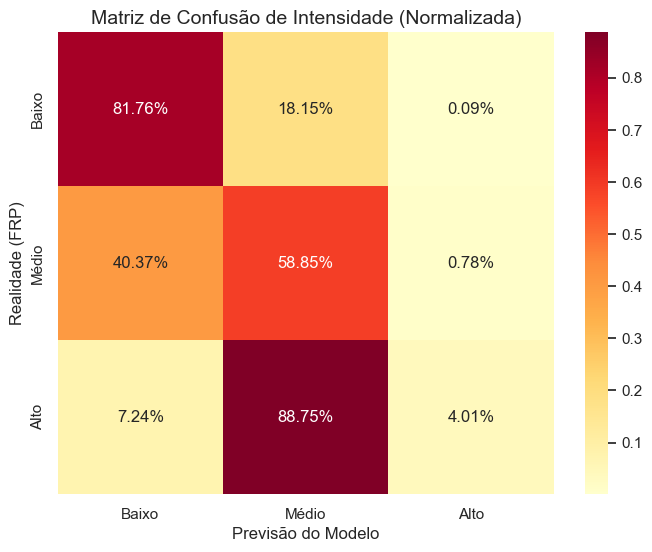

In [22]:
# Calcular a matriz
cm = confusion_matrix(y_test, y_pred, normalize='true')
classes = ['Baixo', 'Médio', 'Alto']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='YlOrRd', 
            xticklabels=classes, yticklabels=classes)

plt.title('Matriz de Confusão de Intensidade (Normalizada)', fontsize=14)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.ylabel('Realidade (FRP)', fontsize=12)
plt.savefig(config_path.REPORTS_DIRECTORY_PATH / '8_matriz_confusao_intensidade.png', dpi=300, bbox_inches='tight')
plt.show()

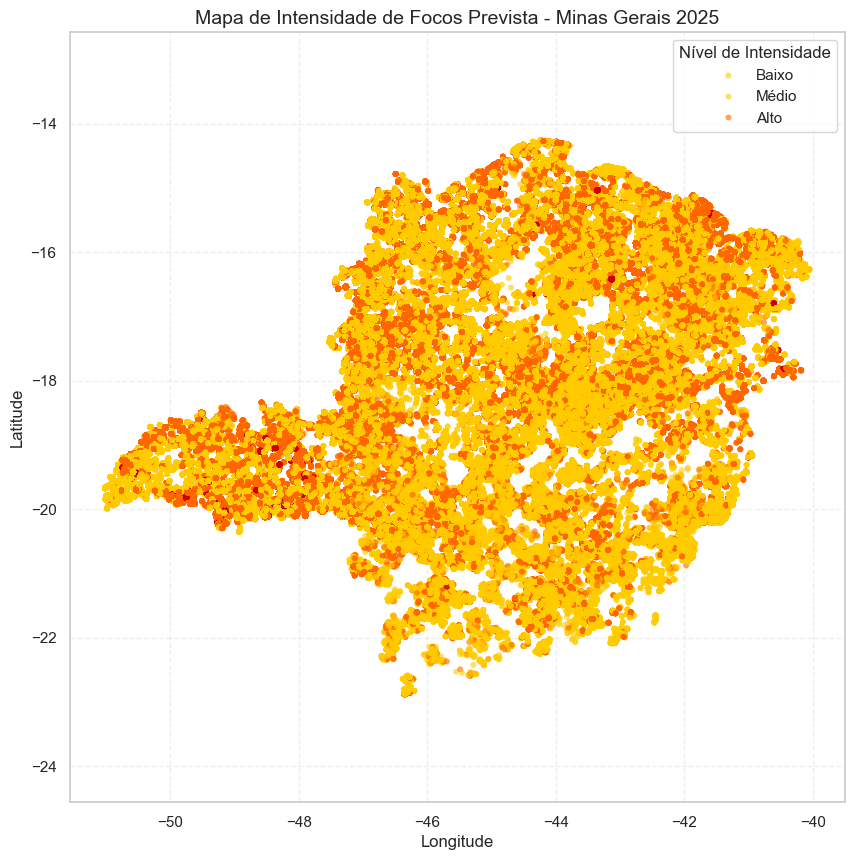

In [23]:
plt.figure(figsize=(10, 10))

# Criamos uma paleta de cores de alerta: Amarelo -> Laranja -> Vermelho
paleta = {0: '#ffcc00', 1: '#ff6600', 2: '#cc0000'}
labels = {0: 'Baixo', 1: 'Médio', 2: 'Alto'}

# Plotamos os pontos de teste
sns.scatterplot(data=X_test, x='Longitude', y='Latitude', 
                hue=y_pred, palette=paleta, s=15, alpha=0.6, edgecolor=None)

plt.title('Mapa de Intensidade de Focos Prevista - Minas Gerais 2025', fontsize=14)
plt.legend(title='Nível de Intensidade', labels=['Baixo', 'Médio', 'Alto'])
plt.axis('equal') 
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig(config_path.REPORTS_DIRECTORY_PATH / '9_mapa_intensidade_prevista.png', dpi=300, bbox_inches='tight')
plt.show()

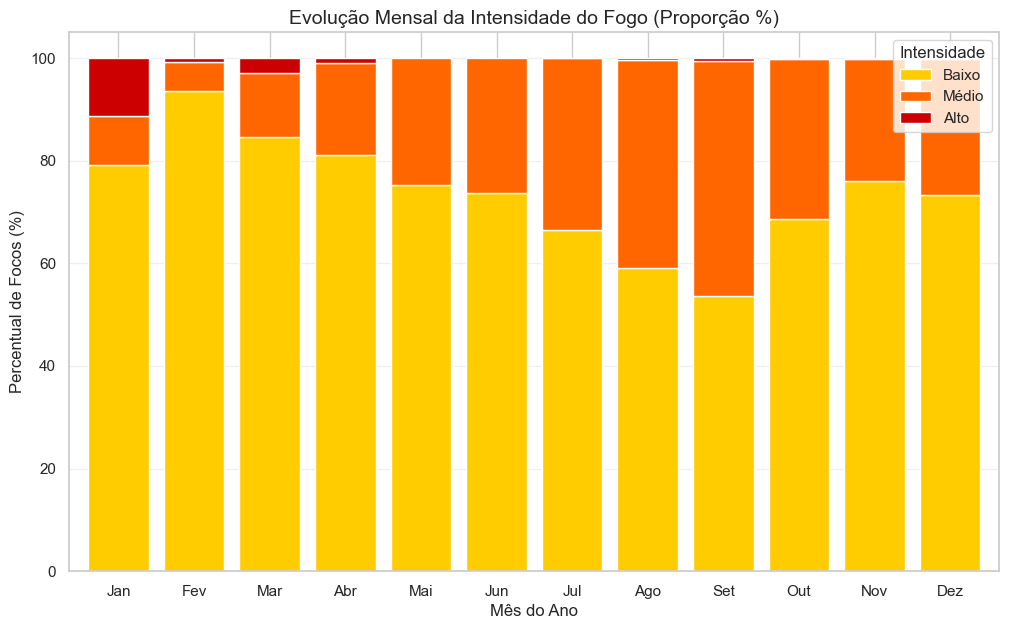

In [24]:
# Criar um DataFrame temporário para o agrupamento
df_plot = X_test.copy()
df_plot['Intensidade'] = y_pred

# Agrupar por mês e intensidade, contando as ocorrências
sazonalidade = df_plot.groupby(['Mes', 'Intensidade']).size().unstack().fillna(0)

# Normalizar para mostrar a proporção (0 a 100%) em cada mês
sazonalidade_pct = sazonalidade.div(sazonalidade.sum(axis=1), axis=0) * 100

ax = sazonalidade_pct.plot(kind='bar', stacked=True, figsize=(12, 7), 
                           color=['#ffcc00', '#ff6600', '#cc0000'], width=0.8)

plt.title('Evolução Mensal da Intensidade do Fogo (Proporção %)', fontsize=14)
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Percentual de Focos (%)', fontsize=12)
plt.xticks(range(0, 12), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'], rotation=0)
plt.legend(['Baixo', 'Médio', 'Alto'], loc='upper right', title='Intensidade')
plt.grid(axis='y', alpha=0.3)
plt.savefig(config_path.REPORTS_DIRECTORY_PATH / '10_evolucao_mensal_intensidade.png', dpi=300, bbox_inches='tight')
plt.show()

### LightGBM - Predição de Queimadas

In [25]:
# --- NOVO PRÉ-PROCESSAMENTO ---

# 1. Limpeza de Outliers e Ruídos (Removendo o -1000 e outros valores inválidos)
# Mantemos apenas registros onde o RiscoFogo faz sentido (entre 0 e 100, por exemplo)
df_completo = df_completo[df_completo['RiscoFogo'] >= 0].copy()

# 2. Normalização (Opcional, mas ajuda muito no R²)
# Vamos transformar a escala original (0 a 50 ou 0 a 100) para uma escala de 0 a 1
scaler_risco = MinMaxScaler()
df_completo['target'] = scaler_risco.fit_transform(df_completo[['RiscoFogo']]).astype(np.float32)

# Salve o scaler para usar na FastAPI depois, senão as escalas não vão bater
# modeling.salvar_modelo_com_metadados(scaler_risco, 'scaler_risco.joblib', TipoModelo.regressao, ['RiscoFogo'])
# joblib.dump(scaler_risco, config_path.MODELS_DIRECTORY_PATH / 'scaler_risco.joblib')

# --- FIM DO PRÉ-PROCESSAMENTO ---

# 4. Divisão Treino e Teste (Respeitando a Cronologia)
df_train = df_completo[df_completo['Ano'] < 2025].copy()
df_test = df_completo[df_completo['Ano'] == 2025].copy()

features = [
    'Satelite', 'Nome_Município', 'Bioma', 'DiaSemChuva', 
    'Precipitacao', 'Latitude', 'Longitude', 'Mes', 'Hora_decimal', 'ID_Município'
]

X_train = df_train[features]
y_train = df_train['target']
X_test = df_test[features]
y_test = df_test['target']

# Tratamento de colunas categóricas
features_categoricas = ['Satelite', 'Nome_Município', 'Bioma']
for col in features_categoricas:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Limpeza de memória
# del df_completo, df_train, df_test
# gc.collect()

# Caminho do modelo de REGRESSÃO
modelo_path = config_path.MODELS_DIRECTORY_PATH / 'preditor_risco_fogo.joblib'

if os.path.exists(modelo_path):
    print("Modelo de Predição já existe. Carregando...")
    model, modelo_info = modeling.carregar_modelo_e_info(modelo_path)  # Carrega o modelo e seus metadados para uso imediato
else:
    # 5. Configuração do LightGBM otimizada para os novos dados limpos
    print("Iniciando o treino do LightGBM Regressor...")
    model = lgb.LGBMRegressor(
        objective='regression',
        n_estimators=3000,      # Aumentado para buscar melhor R²
        learning_rate=0.03,      # Menor para um aprendizado mais refinado
        num_leaves=128,          # Aumentado para capturar padrões complexos
        max_depth=-1,
        min_child_samples=20,
        n_jobs=-1,
        random_state=42,
        importance_type='gain'
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=150)] # Aumentado o fôlego do treino
    )
    
    modeling.salvar_modelo_com_metadados(model, 'preditor_risco_fogo.joblib', TipoModelo.regressao, features)

# 6. Avaliação da Predição
y_pred = model.predict(X_test)

# Calculando as métricas base
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
# O MAPE pode dar erro se houver zeros no y_test, por isso tratamos:
mape = mean_absolute_percentage_error(y_test, y_pred) if np.all(y_test > 0) else None

print("\n--- MÉTRICAS DE REGRESSÃO EXPANDIDAS ---")
print(f"MAE (Erro Médio Absoluto): {mae:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}  <-- Sensível a outliers")
print(f"RMSE (Raiz do Erro Quadrático): {rmse:.4f} <-- Na escala original")
print(f"R² Score: {r2:.4f}")
if mape: print(f"MAPE (Erro Percentual): {mape*100:.2f}%")

Modelo de Predição já existe. Carregando...

--- MÉTRICAS DE REGRESSÃO EXPANDIDAS ---
MAE (Erro Médio Absoluto): 0.1034
MSE (Erro Quadrático Médio): 0.0326  <-- Sensível a outliers
RMSE (Raiz do Erro Quadrático): 0.1805 <-- Na escala original
R² Score: 0.6549


In [26]:
modeling.salvar_metricas_regressao({
    "mae": mae,
    "mse": mse,
    "rmse": rmse,
    "r2": r2,
    "mape": mape
}, "preditor_risco_fogo.joblib")

print(modeling.carregar_metricas_regressao("preditor_risco_fogo.joblib"))

✅ Métricas de regressão salvas: d:\projetos_github\Desafio-3-ZettaLab-2ed\metrics\metrics_reg_preditor_risco_fogo.joblib
mae=0.10337941059043107 mse=0.032579116620603234 rmse=0.18049686041757965 r2=0.6549296405554079 mape=None


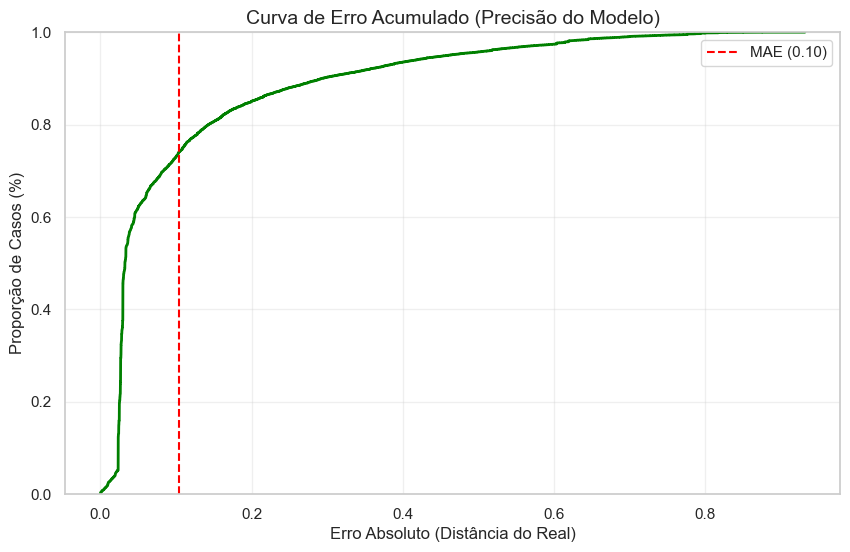

In [27]:
plt.figure(figsize=(10, 6))

# Calculando erro absoluto
erro_abs = np.abs(y_test - y_pred)
sns.ecdfplot(erro_abs, color='green', lw=2)

plt.axvline(0.1034, color='red', linestyle='--', label='MAE (0.10)')
plt.title('Curva de Erro Acumulado (Precisão do Modelo)', fontsize=14)
plt.xlabel('Erro Absoluto (Distância do Real)')
plt.ylabel('Proporção de Casos (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(config_path.REPORTS_DIRECTORY_PATH / '11_curva_erro_acumulado.png', dpi=300, bbox_inches='tight')
plt.show()

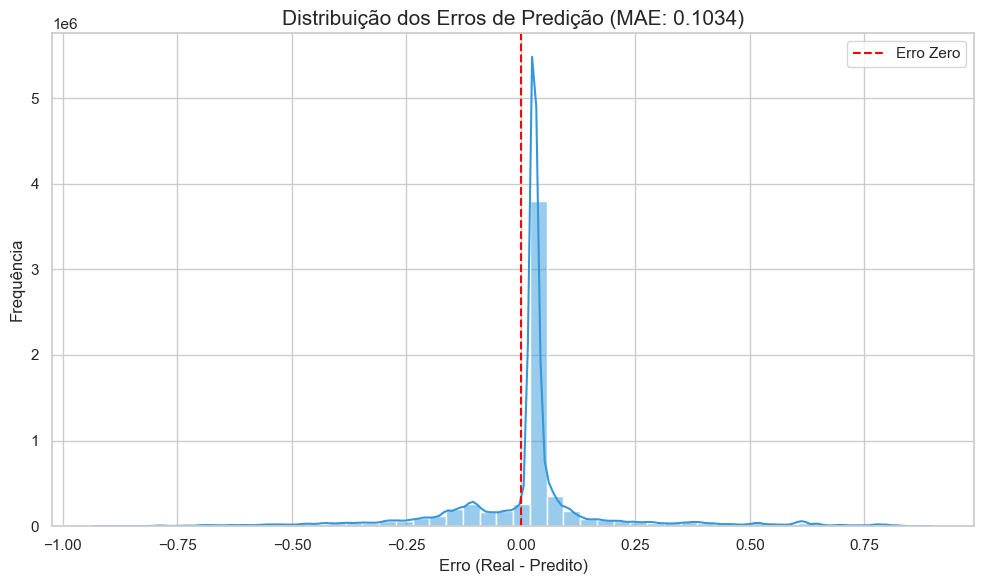

In [28]:
plt.figure(figsize=(10, 6))

# Calculando os resíduos
residuos = y_test - y_pred

# Histograma com curva de densidade
sns.histplot(residuos, kde=True, color="#3498db", bins=50)

plt.axvline(0, color='red', linestyle='--', label='Erro Zero')
plt.title(f'Distribuição dos Erros de Predição (MAE: {0.1034:.4f})', fontsize=15)
plt.xlabel('Erro (Real - Predito)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(config_path.REPORTS_DIRECTORY_PATH / '12_distribuicao_erros.png', dpi=300, bbox_inches='tight')
plt.show()

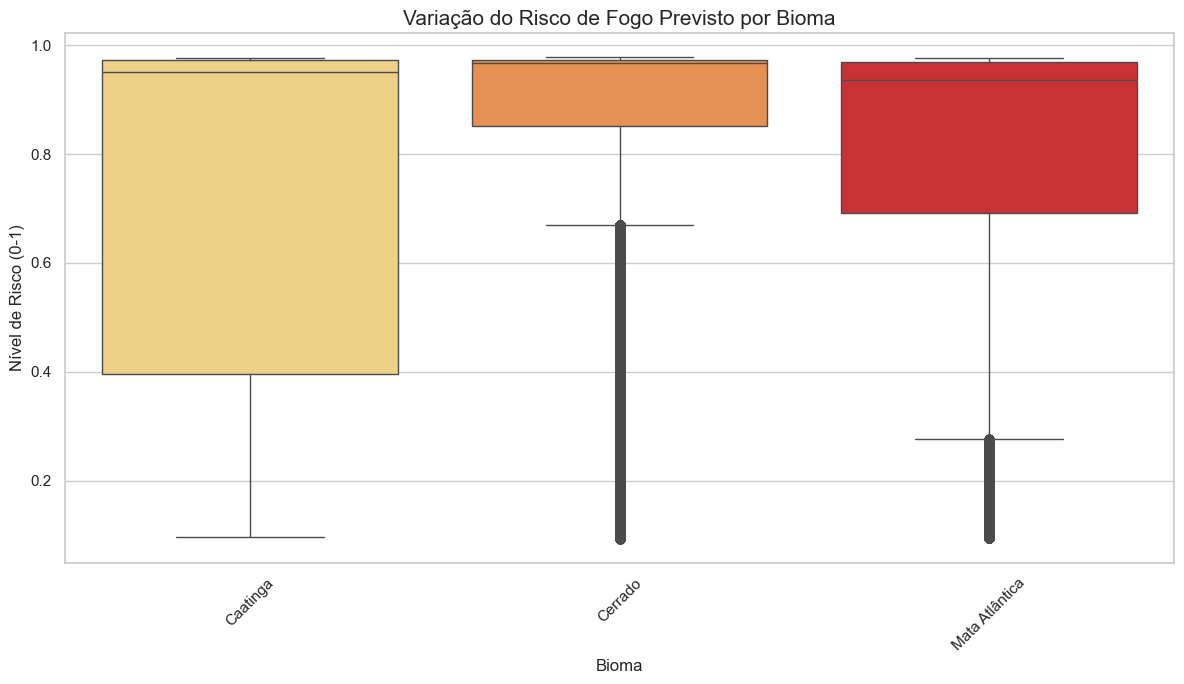

In [29]:
plt.figure(figsize=(12, 7))

# Criando um DF temporário para o gráfico
df_analise = X_test.copy()
df_analise['Risco_Predito'] = y_pred

# Boxplot para ver a variação de risco em cada bioma
sns.boxplot(data=df_analise, x='Bioma', y='Risco_Predito', palette="YlOrRd")

plt.title('Variação do Risco de Fogo Previsto por Bioma', fontsize=15)
plt.xlabel('Bioma', fontsize=12)
plt.ylabel('Nível de Risco (0-1)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(config_path.REPORTS_DIRECTORY_PATH / '13_boxplot_risco_bioma.png', dpi=300, bbox_inches='tight')
plt.show()

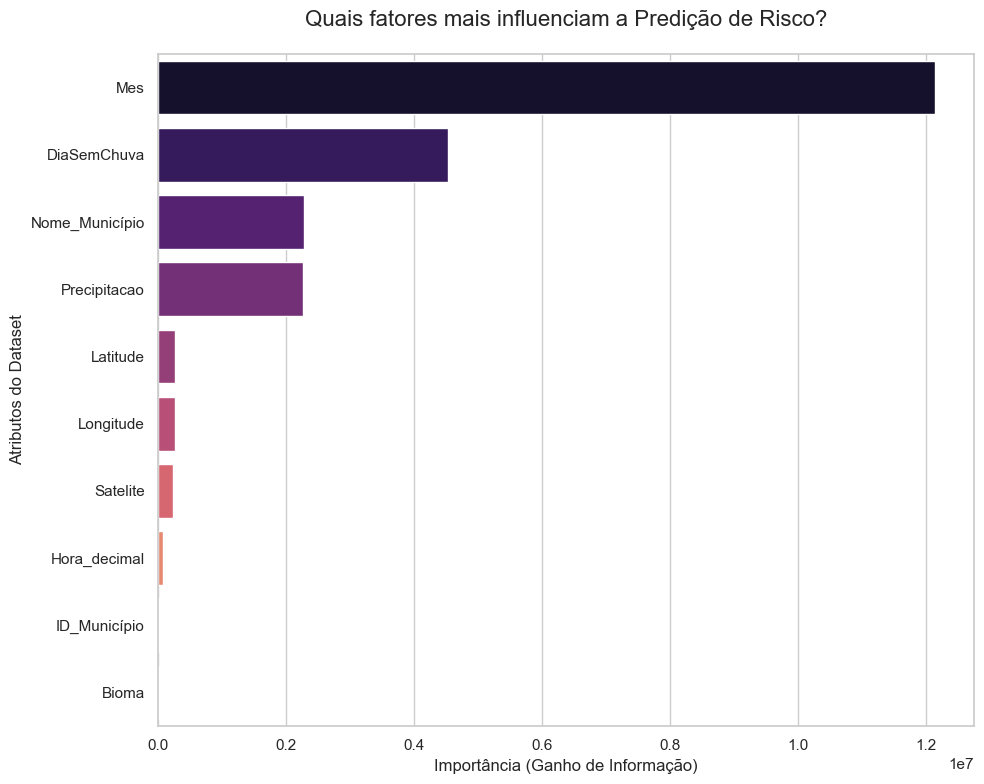

In [30]:
# 1. Extrair a importância das colunas do modelo treinado
# O LightGBM já calculou isso durante o .fit()
importancia = model.feature_importances_

# 2. Criar um DataFrame para facilitar a plotagem com Seaborn
df_importancia = pd.DataFrame({
    'Atributo': features,
    'Importancia': importancia
})

# Ordenar do maior para o menor para o gráfico ficar em cascata
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 3. Configurar a estética do gráfico
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Criar o gráfico de barras
grafico = sns.barplot(
    data=df_importancia, 
    x='Importancia', 
    y='Atributo', 
    palette='magma' # Paleta de cores do roxo ao amarelo (estilo "quente")
)

# Adicionar títulos e rótulos
plt.title('Quais fatores mais influenciam a Predição de Risco?', fontsize=16, pad=20)
plt.xlabel('Importância (Ganho de Informação)', fontsize=12)
plt.ylabel('Atributos do Dataset', fontsize=12)

# Ajustar layout para não cortar os nomes das cidades/biomas
plt.tight_layout()
plt.savefig(config_path.REPORTS_DIRECTORY_PATH / '14_importancia_atributos.png', dpi=300, bbox_inches='tight')
plt.show()